# Experiment 4: Cross-Domain Knowledge Distillation

## Core Idea
The NF-UQ model (NetFlowDetector) has learned strong attack discrimination thanks to native NetFlow features (PROTOCOL, TCP_FLAGS, packet-level granularity).  
We **transfer class-discriminative knowledge** from the UQ **teacher** to the CIC **student** via latent space alignment.

## Architecture
```
┌─────────────────────────────────────────────────────────────────────┐
│  UQ TEACHER (frozen)                                                │
│  UQ features → NetFlowDetector → 32-dim embedding → soft logits    │
│       ↓ Extract class centroids + soft label distributions          │
└──────────────────────────────┬──────────────────────────────────────┘
                               │ Knowledge Transfer
┌──────────────────────────────▼──────────────────────────────────────┐
│  CIC STUDENT (trainable)                                            │
│  CIC features → Backbone → 32-dim embedding ──→ Classification head │
│                                    │                                │
│                              Projection head → 32-dim "UQ-aligned"  │
│                                    │                                │
│                    Align with UQ class centroids (MSE)              │
└─────────────────────────────────────────────────────────────────────┘
```

## Training Losses
1. **Classification Loss**: AsymmetricFocalLoss on CIC labels (standard supervised)
2. **KD Loss**: KL-divergence between student logits and teacher's soft distribution per class
3. **Centroid Alignment**: MSE between projected CIC embedding and UQ teacher centroid of same class
4. **Contrastive Separation**: Triplet-like loss pushing hard-to-distinguish attacks apart in embedding space
5. **Synthetic Augmentation**: Generate hard examples at decision boundaries for difficult attacks

## 1. Imports & Config

In [1]:
import os, pickle, warnings, copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, accuracy_score)
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────
BASE_DIR = "/home/huyho/earth_predict_env"
DATA_DIR = f"{BASE_DIR}/Project/dataset"
SAVE_DIR = f"{BASE_DIR}/Project/Model/Domain_Adaption"
os.makedirs(SAVE_DIR, exist_ok=True)

NFUQ_PARQUET = f"{DATA_DIR}/nf_uq_balanced_dataset.parquet"
CIC17_CSV    = f"{DATA_DIR}/cicids2017_sample_1M_natural_standardized.csv"
CIC18_PQ     = f"{DATA_DIR}/cic2018_balanced_dataset_standardized.parquet"

# ── Device ─────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ── Constants ──────────────────────────────────────────────────────
NUM_CLASSES      = 5
UNIFIED_CLASSES  = ['Benign', 'BruteForce', 'DDoS', 'DoS', 'Infiltration']
BATCH_SIZE       = 256
SEED             = 42

# ── NF-UQ: ALL 39 features ────────────────────────────────────────
NFUQ_FEATURES = [
    'PROTOCOL', 'L7_PROTO',
    'IN_BYTES', 'IN_PKTS', 'OUT_BYTES', 'OUT_PKTS',
    'TCP_FLAGS', 'CLIENT_TCP_FLAGS', 'SERVER_TCP_FLAGS',
    'FLOW_DURATION_MILLISECONDS',
    'DURATION_IN', 'DURATION_OUT',
    'MIN_TTL', 'MAX_TTL',
    'LONGEST_FLOW_PKT', 'SHORTEST_FLOW_PKT',
    'MIN_IP_PKT_LEN', 'MAX_IP_PKT_LEN',
    'SRC_TO_DST_SECOND_BYTES', 'DST_TO_SRC_SECOND_BYTES',
    'RETRANSMITTED_IN_BYTES', 'RETRANSMITTED_IN_PKTS',
    'RETRANSMITTED_OUT_BYTES', 'RETRANSMITTED_OUT_PKTS',
    'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT',
    'NUM_PKTS_UP_TO_128_BYTES', 'NUM_PKTS_128_TO_256_BYTES',
    'NUM_PKTS_256_TO_512_BYTES', 'NUM_PKTS_512_TO_1024_BYTES',
    'NUM_PKTS_1024_TO_1514_BYTES',
    'TCP_WIN_MAX_IN', 'TCP_WIN_MAX_OUT',
    'ICMP_TYPE', 'ICMP_IPV4_TYPE',
    'DNS_QUERY_ID', 'DNS_QUERY_TYPE', 'DNS_TTL_ANSWER',
    'FTP_COMMAND_RET_CODE',
]

# ── CIC: ALL 78 common features (shared by CIC-2017 & CIC-2018) ──
CIC_FEATURES = [
    'Dst Port', 'Flow Duration',
    'Tot Fwd Pkts', 'Tot Bwd Pkts',
    'TotLen Fwd Pkts', 'TotLen Bwd Pkts',
    'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
    'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std',
    'Flow Byts/s', 'Flow Pkts/s',
    'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
    'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
    'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min',
    'Fwd PSH Flags', 'Bwd PSH Flags',
    'Fwd URG Flags', 'Bwd URG Flags',
    'Fwd Header Len', 'Bwd Header Len',
    'Fwd Packets/s', 'Bwd Packets/s',
    'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var',
    'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt',
    'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt',
    'Down/Up Ratio', 'Pkt Size Avg',
    'Fwd Seg Size Avg', 'Bwd Seg Size Avg',
    'Fwd Header Length.1',
    'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg',
    'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg',
    'Subflow Fwd Pkts', 'Subflow Fwd Byts',
    'Subflow Bwd Pkts', 'Subflow Bwd Byts',
    'Init Fwd Win Byts', 'Init Bwd Win Byts',
    'Fwd Act Data Pkts', 'Fwd Seg Size Min',
    'Active Mean', 'Active Std', 'Active Max', 'Active Min',
    'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min',
]

# ── Label Mappings ─────────────────────────────────────────────────
CIC17_LABEL_MAP = {
    'BENIGN': 'Benign',
    'DoS Hulk': 'DoS', 'DoS GoldenEye': 'DoS',
    'DoS slowloris': 'DoS', 'DoS Slowhttptest': 'DoS',
    'DDoS': 'DDoS',
    'FTP-Patator': 'BruteForce', 'SSH-Patator': 'BruteForce',
    'Web Attack � Brute Force': 'BruteForce',
    'Web Attack � XSS': 'BruteForce',
    'Infiltration': 'Infiltration',
    'Heartbleed': 'Infiltration',
}

CIC18_LABEL_MAP = {
    'Benign': 'Benign',
    'DoS attacks-GoldenEye': 'DoS', 'DoS attacks-Hulk': 'DoS',
    'DoS attacks-Slowloris': 'DoS', 'DoS attacks-SlowHTTPTest': 'BruteForce',
    'DDoS attacks-LOIC-HTTP': 'DDoS', 'DDOS attack-HOIC': 'DDoS',
    'DDOS attack-LOIC-UDP': 'DDoS',
    'FTP-BruteForce': 'BruteForce', 'SSH-Bruteforce': 'BruteForce',
    'Brute Force -Web': 'BruteForce', 'Brute Force -XSS': 'BruteForce',
    'Infilteration': 'Infiltration',
}

# ── Per-class loss parameters ──────────────────────────────────────
#                    [Benign, BruteForce, DDoS, DoS,  Infiltration]
CLASS_GAMMAS = [1.0,    2.5,       1.5,  2.0,  4.0]   # DoS: 3.0→2.0, Infiltration: 3.5→4.0
FN_BOOST     = [1.0,    2.0,       1.5,  2.0,  4.0]   # DoS: 2.5→2.0, Infiltration: 3.0→4.0

print(f"Unified classes: {UNIFIED_CLASSES}")
print(f"NF-UQ features: {len(NFUQ_FEATURES)}, CIC features: {len(CIC_FEATURES)}")
print(f"CLASS_GAMMAS: {CLASS_GAMMAS}")
print(f"FN_BOOST:     {FN_BOOST}")

Device: cuda
Unified classes: ['Benign', 'BruteForce', 'DDoS', 'DoS', 'Infiltration']
NF-UQ features: 39, CIC features: 78
CLASS_GAMMAS: [1.0, 2.5, 1.5, 2.0, 4.0]
FN_BOOST:     [1.0, 2.0, 1.5, 2.0, 4.0]


## 2. Helper Functions

In [2]:
def clean_df(df, feature_cols):
    """Replace inf/NaN in feature columns with 0."""
    for c in feature_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')
            df[c] = df[c].replace([np.inf, -np.inf], np.nan).fillna(0)
    return df

def undersample_majority(X, y, majority_idx, max_ratio=15.0):
    """Downsample majority class so it's at most max_ratio × smallest minority."""
    from collections import Counter
    counts = Counter(y)
    min_count = min(c for cls, c in counts.items() if cls != majority_idx)
    cap = int(min_count * max_ratio)
    if counts[majority_idx] <= cap:
        return X, y
    maj_mask = (y == majority_idx)
    maj_idx = np.where(maj_mask)[0]
    rng = np.random.RandomState(SEED)
    keep = rng.choice(maj_idx, size=cap, replace=False)
    keep = np.sort(np.concatenate([np.where(~maj_mask)[0], keep]))
    return X[keep], y[keep]

def make_asymmetric_weights(class_weights, fn_boost, device):
    """Multiply balanced class weights by per-class FN boost factors."""
    w = torch.tensor(class_weights, dtype=torch.float32)
    b = torch.tensor(fn_boost, dtype=torch.float32)
    return (w * b).to(device)

def make_loader(X, y, batch_size=BATCH_SIZE, shuffle=True):
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32),
                       torch.tensor(y, dtype=torch.long))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=False)

@torch.no_grad()
def eval_model_logits(model, loader, device, dataset_id=None):
    """Return predictions, true labels, and raw logits."""
    model.eval()
    all_preds, all_true, all_logits = [], [], []
    for Xb, yb in loader:
        Xb = Xb.to(device)
        if dataset_id is not None:
            logits = model(Xb, dataset_id)
        else:
            logits = model(Xb)
        all_logits.append(logits.cpu())
        all_preds.append(logits.argmax(1).cpu())
        all_true.append(yb)
    return (torch.cat(all_preds).numpy(),
            torch.cat(all_true).numpy(),
            torch.cat(all_logits))

def plot_confusion(y_true, y_pred, classes, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(classes))))
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)
    plt.tight_layout(); plt.show()

print("Helpers defined.")

Helpers defined.


## 3. Load & Prepare Datasets
Load NF-UQ, CIC-2017, and CIC-2018 with unified 5-class labels:  
**Benign, BruteForce, DDoS, DoS, Infiltration**

In [3]:
# ═══════════════════════════════════════════════════════════════════
# 3a. NF-UQ Dataset (with SMOTE for Infiltration minority class)
# ═══════════════════════════════════════════════════════════════════
from imblearn.over_sampling import SMOTE

df_nfuq = pd.read_parquet(NFUQ_PARQUET)
df_nfuq['Label'] = df_nfuq['Label'].replace({
    'Brute Force': 'BruteForce',
    'Infilteration': 'Infiltration'
})
df_nfuq = df_nfuq[df_nfuq['Label'].isin(UNIFIED_CLASSES)].copy()
df_nfuq = clean_df(df_nfuq, NFUQ_FEATURES)

nfuq_le = LabelEncoder().fit(UNIFIED_CLASSES)
y_nfuq  = nfuq_le.transform(df_nfuq['Label'].values)
X_nfuq  = df_nfuq[NFUQ_FEATURES].values.astype(np.float32)

# 70/10/20 split
Xnf_tv, Xnf_te, ynf_tv, ynf_te = train_test_split(
    X_nfuq, y_nfuq, test_size=0.20, stratify=y_nfuq, random_state=SEED)
Xnf_tr, Xnf_va, ynf_tr, ynf_va = train_test_split(
    Xnf_tv, ynf_tv, test_size=0.10/(1-0.20), stratify=ynf_tv, random_state=SEED)

# ── SMOTE oversampling for Infiltration ──
# Boost Infiltration to match at least 50% of the median class size
from collections import Counter
counts_before = Counter(ynf_tr)
infil_idx = nfuq_le.transform(['Infiltration'])[0]
benign_idx_nf = nfuq_le.transform(['Benign'])[0]
median_count = int(np.median(list(counts_before.values())))
target_infil = max(counts_before[infil_idx], median_count)

# Only SMOTE the classes that need it (Infiltration), keep others unchanged
sampling_strategy = {c: max(cnt, target_infil) for c, cnt in counts_before.items()}
smote = SMOTE(sampling_strategy=sampling_strategy, random_state=SEED, k_neighbors=min(5, counts_before[infil_idx]-1))
Xnf_tr, ynf_tr = smote.fit_resample(Xnf_tr, ynf_tr)
Xnf_tr = Xnf_tr.astype(np.float32)

counts_after = Counter(ynf_tr)
print(f"SMOTE: Infiltration {counts_before[infil_idx]} → {counts_after[infil_idx]}")

nfuq_scaler = StandardScaler().fit(Xnf_tr)
Xnf_tr_sc = nfuq_scaler.transform(Xnf_tr).astype(np.float32)
Xnf_va_sc = nfuq_scaler.transform(Xnf_va).astype(np.float32)
Xnf_te_sc = nfuq_scaler.transform(Xnf_te).astype(np.float32)

print(f"NF-UQ  → train: {Xnf_tr_sc.shape}, val: {Xnf_va_sc.shape}, test: {Xnf_te_sc.shape}")
print(f"   Class dist (train after SMOTE): {dict(zip(*np.unique(ynf_tr, return_counts=True)))}")

SMOTE: Infiltration 81453 → 209999
NF-UQ  → train: (1119996, 39), val: (124035, 39), test: (248069, 39)
   Class dist (train after SMOTE): {np.int64(0): np.int64(279999), np.int64(1): np.int64(209999), np.int64(2): np.int64(210000), np.int64(3): np.int64(209999), np.int64(4): np.int64(209999)}


In [4]:
# ═══════════════════════════════════════════════════════════════════
# 3b. CIC-2017 Dataset
# ═══════════════════════════════════════════════════════════════════
df17 = pd.read_csv(CIC17_CSV)
df17['Label'] = df17['Label'].str.replace('\ufffd', '?', regex=False)
df17['Label_grouped'] = df17['Label'].map(
    {k.replace('\xef\xbf\xbd', '?'): v for k, v in CIC17_LABEL_MAP.items()})
df17 = df17[df17['Label_grouped'].isin(UNIFIED_CLASSES)].copy()
df17 = clean_df(df17, CIC_FEATURES)

cic17_le = LabelEncoder().fit(UNIFIED_CLASSES)
y17 = cic17_le.transform(df17['Label_grouped'].values)
X17 = df17[CIC_FEATURES].values.astype(np.float32)

X17_tv, X17_te, y17_tv, y17_te = train_test_split(
    X17, y17, test_size=0.20, stratify=y17, random_state=SEED)
X17_tr, X17_va, y17_tr, y17_va = train_test_split(
    X17_tv, y17_tv, test_size=0.10/(1-0.20), stratify=y17_tv, random_state=SEED)

# Undersample benign to 15× minority
benign_idx = cic17_le.transform(['Benign'])[0]
X17_tr, y17_tr = undersample_majority(X17_tr, y17_tr, majority_idx=benign_idx, max_ratio=15.0)

cic17_scaler = StandardScaler().fit(X17_tr)
X17_tr_sc = cic17_scaler.transform(X17_tr).astype(np.float32)
X17_va_sc = cic17_scaler.transform(X17_va).astype(np.float32)
X17_te_sc = cic17_scaler.transform(X17_te).astype(np.float32)

print(f"CIC-17 → train: {X17_tr_sc.shape}, val: {X17_va_sc.shape}, test: {X17_te_sc.shape}")
print(f"   Class dist (train): {dict(zip(*np.unique(y17_tr, return_counts=True)))}")

CIC-17 → train: (155989, 78), val: (86280, 78), test: (172560, 78)
   Class dist (train): {np.int64(0): np.int64(480), np.int64(1): np.int64(5499), np.int64(2): np.int64(50472), np.int64(3): np.int64(99506), np.int64(4): np.int64(32)}


In [5]:
# ═══════════════════════════════════════════════════════════════════
# 3c. CIC-2018 Dataset
# ═══════════════════════════════════════════════════════════════════
df18 = pd.read_parquet(CIC18_PQ)
df18['Label_grouped'] = df18['Label'].map(CIC18_LABEL_MAP)
df18 = df18[df18['Label_grouped'].isin(UNIFIED_CLASSES)].copy()
df18 = clean_df(df18, CIC_FEATURES)

cic18_le = LabelEncoder().fit(UNIFIED_CLASSES)
y18 = cic18_le.transform(df18['Label_grouped'].values)
X18 = df18[CIC_FEATURES].values.astype(np.float32)

X18_tv, X18_te, y18_tv, y18_te = train_test_split(
    X18, y18, test_size=0.20, stratify=y18, random_state=SEED)
X18_tr, X18_va, y18_tr, y18_va = train_test_split(
    X18_tv, y18_tv, test_size=0.10/(1-0.20), stratify=y18_tv, random_state=SEED)

cic18_scaler = StandardScaler().fit(X18_tr)
X18_tr_sc = cic18_scaler.transform(X18_tr).astype(np.float32)
X18_va_sc = cic18_scaler.transform(X18_va).astype(np.float32)
X18_te_sc = cic18_scaler.transform(X18_te).astype(np.float32)

print(f"CIC-18 → train: {X18_tr_sc.shape}, val: {X18_va_sc.shape}, test: {X18_te_sc.shape}")
print(f"   Class dist (train): {dict(zip(*np.unique(y18_tr, return_counts=True)))}")

# ── Build DataLoaders ──────────────────────────────────────────────
nfuq_train_loader = make_loader(Xnf_tr_sc, ynf_tr)
nfuq_val_loader   = make_loader(Xnf_va_sc, ynf_va, shuffle=False)
nfuq_test_loader  = make_loader(Xnf_te_sc, ynf_te, shuffle=False)

c17_train_loader = make_loader(X17_tr_sc, y17_tr)
c17_val_loader   = make_loader(X17_va_sc, y17_va, shuffle=False)
c17_test_loader  = make_loader(X17_te_sc, y17_te, shuffle=False)

c18_train_loader = make_loader(X18_tr_sc, y18_tr)
c18_val_loader   = make_loader(X18_va_sc, y18_va, shuffle=False)
c18_test_loader  = make_loader(X18_te_sc, y18_te, shuffle=False)

print("\nAll DataLoaders ready.")

CIC-18 → train: (184492, 78), val: (26356, 78), test: (52712, 78)
   Class dist (train): {np.int64(0): np.int64(34999), np.int64(1): np.int64(53089), np.int64(2): np.int64(36211), np.int64(3): np.int64(42693), np.int64(4): np.int64(17500)}

All DataLoaders ready.


## 4. Model Definitions

### Teacher: `NetFlowDetector` (frozen, pre-trained on NF-UQ)
- Provides **32-dim class centroids** and **soft label distributions** per class
- Feature space is completely different from CIC → needs a projection bridge

### Student: `CICDistillStudent`
- Backbone similar to `UnifiedCICDetector` but with an additional **projection head** to map into the UQ teacher's 32-dim space
- **Classification head**: standard linear layer → 5 classes
- **Projection head**: maps 64-dim backbone embedding → 32-dim UQ-aligned space for centroid alignment

In [6]:
# ═══════════════════════════════════════════════════════════════════
# 4a. Loss Functions
# ═══════════════════════════════════════════════════════════════════

class AsymmetricFocalLoss(nn.Module):
    """Focal loss with per-class gamma and class weights."""
    def __init__(self, weight=None, gamma=2.0, class_gamma=None):
        super().__init__()
        self.weight = weight
        self.gamma = gamma
        self.class_gamma = class_gamma

    def forward(self, logits, targets):
        log_prob = F.log_softmax(logits, dim=1)
        pt = log_prob.exp().gather(1, targets.unsqueeze(1)).squeeze(1)
        if self.class_gamma is not None:
            gamma_per_sample = self.class_gamma[targets]
        else:
            gamma_per_sample = self.gamma
        focal_weight = (1 - pt) ** gamma_per_sample
        loss = -focal_weight * log_prob.gather(1, targets.unsqueeze(1)).squeeze(1)
        if self.weight is not None:
            loss = loss * self.weight[targets]
        return loss.mean()


class CORALLoss(nn.Module):
    """Aligns second-order statistics between two embedding distributions."""
    def forward(self, feat_a, feat_b):
        d = feat_a.size(1)
        cov_a = (feat_a - feat_a.mean(0)).t() @ (feat_a - feat_a.mean(0)) / max(feat_a.size(0)-1, 1)
        cov_b = (feat_b - feat_b.mean(0)).t() @ (feat_b - feat_b.mean(0)) / max(feat_b.size(0)-1, 1)
        return (cov_a - cov_b).pow(2).sum() / (4 * d * d)


print("Loss functions defined.")

Loss functions defined.


In [7]:
# ═══════════════════════════════════════════════════════════════════
# 4b. Teacher Model: Enhanced NetFlowDetector
# ═══════════════════════════════════════════════════════════════════

class FeatureAttention(nn.Module):
    """Learn which input features are most discriminative (e.g., for Benign vs Infiltration)."""
    def __init__(self, input_size, reduction=4):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(input_size, input_size // reduction),
            nn.ReLU(),
            nn.Linear(input_size // reduction, input_size),
            nn.Sigmoid()
        )
    def forward(self, x):
        return x * self.attn(x)


class NetFlowDetector(nn.Module):
    """
    Enhanced NF-UQ teacher with:
    - Feature attention (learns discriminative feature weights)
    - Wider layers: 39→256→128→64→32 (was 128→64→32)
    - Residual connection in the deep layers
    - Auxiliary binary head: Benign(0) vs Infiltration(4) classifier
    """
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.feature_attn = FeatureAttention(input_size)
        
        self.layer1 = nn.Sequential(
            nn.Linear(input_size, 256), nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(0.3))
        self.layer2 = nn.Sequential(
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.GELU(), nn.Dropout(0.2))
        self.layer3 = nn.Sequential(
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.GELU(), nn.Dropout(0.15))
        self.layer4 = nn.Sequential(
            nn.Linear(64, 32), nn.BatchNorm1d(32), nn.GELU(), nn.Dropout(0.1))
        
        # Residual: project layer2 output (128-dim) → 32-dim for skip connection
        self.skip_proj = nn.Linear(128, 32)
        
        # Main classification head
        self.head = nn.Linear(32, num_classes)
        
        # Auxiliary binary head: Benign vs Infiltration
        # Operates on the 32-dim embedding to give explicit gradient signal
        self.aux_head = nn.Linear(32, 2)

    def get_embedding(self, x):
        x = self.feature_attn(x)
        h1 = self.layer1(x)
        h2 = self.layer2(h1)
        h3 = self.layer3(h2)
        h4 = self.layer4(h3)
        return h4 + 0.3 * self.skip_proj(h2)  # residual from layer2

    def forward(self, x):
        return self.head(self.get_embedding(x))
    
    def forward_aux(self, x):
        """Return main logits + auxiliary Benign-vs-Infiltration logits."""
        emb = self.get_embedding(x)
        return self.head(emb), self.aux_head(emb)


class CenterLoss(nn.Module):
    """Pulls embeddings toward their class center; makes clusters tighter."""
    def __init__(self, num_classes, feat_dim):
        super().__init__()
        self.centers = nn.Parameter(torch.randn(num_classes, feat_dim))
    
    def forward(self, embeddings, targets):
        target_centers = self.centers[targets]
        return F.mse_loss(embeddings, target_centers)


total_teacher_params = sum(p.numel() for p in NetFlowDetector(39, 5).parameters())
print(f"Enhanced NetFlowDetector defined — {total_teacher_params:,} parameters")
print("  + Feature Attention → learns discriminative feature weights")
print("  + Residual connection (layer2 → embedding)")
print("  + Auxiliary binary head (Benign vs Infiltration)")
print("CenterLoss defined.")

Enhanced NetFlowDetector defined — 59,541 parameters
  + Feature Attention → learns discriminative feature weights
  + Residual connection (layer2 → embedding)
  + Auxiliary binary head (Benign vs Infiltration)
CenterLoss defined.


In [8]:
# ═══════════════════════════════════════════════════════════════════
# 4c. Student Model: CICDistillStudent
# ═══════════════════════════════════════════════════════════════════

class CICDistillStudent(nn.Module):
    """
    CIC student with projection head for UQ teacher alignment.
    
    Backbone: 32 features → 512 → 256 → 128 → 64 (+ skip from layer2)
    Classification head: 64 → num_classes (for CIC-17 and CIC-18)
    Projection head: 64 → 32 (maps into UQ teacher's 32-dim embedding space)
    """
    def __init__(self, input_size, num_classes_17, num_classes_18, teacher_embed_dim=32):
        super().__init__()
        # Backbone (same architecture as UnifiedCICDetector)
        self.layer1 = nn.Sequential(
            nn.Linear(input_size, 512), nn.BatchNorm1d(512), nn.GELU(), nn.Dropout(0.3))
        self.layer2 = nn.Sequential(
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(0.3))
        self.layer3 = nn.Sequential(
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.GELU(), nn.Dropout(0.2))
        self.layer4 = nn.Sequential(
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.GELU(), nn.Dropout(0.1))
        self.skip_proj = nn.Linear(256, 64)  # skip connection: layer2 → embedding
        self.embed_dim = 64

        # Classification heads (dual: one per CIC dataset)
        self.head_cic17 = nn.Linear(64, num_classes_17)
        self.head_cic18 = nn.Linear(64, num_classes_18)

        # Projection head: maps backbone embedding → teacher's embedding space
        self.projection = nn.Sequential(
            nn.Linear(64, 48), nn.BatchNorm1d(48), nn.GELU(),
            nn.Linear(48, teacher_embed_dim)
        )

    def get_embedding(self, x):
        h1 = self.layer1(x)
        h2 = self.layer2(h1)
        h3 = self.layer3(h2)
        h4 = self.layer4(h3)
        return h4 + 0.3 * self.skip_proj(h2)

    def get_projection(self, x):
        """Get 32-dim projection aligned with UQ teacher space."""
        emb = self.get_embedding(x)
        return self.projection(emb)

    def forward(self, x, dataset_id):
        """dataset_id: 0 = CIC-2017, 1 = CIC-2018"""
        emb = self.get_embedding(x)
        if dataset_id == 0:
            return self.head_cic17(emb)
        else:
            return self.head_cic18(emb)

    def forward_all(self, x, dataset_id):
        """Return logits + projection for distillation training."""
        emb = self.get_embedding(x)
        proj = self.projection(emb)
        logits = self.head_cic17(emb) if dataset_id == 0 else self.head_cic18(emb)
        return logits, proj


total_params = sum(p.numel() for p in CICDistillStudent(len(CIC_FEATURES), NUM_CLASSES, NUM_CLASSES).parameters())
print(f"CICDistillStudent defined — {total_params:,} parameters")

CICDistillStudent defined — 236,730 parameters


## 5. Train NF-UQ Teacher
Train `NetFlowDetector` on NF-UQ data, then **freeze** it and extract:
1. **Class centroids**: mean 32-dim embedding per class
2. **Soft label distributions**: average softmax output per class (temperature-scaled)

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# 5a. Train Enhanced NetFlowDetector (NF-UQ Teacher)
#     + Auxiliary Benign-vs-Infiltration loss
#     + Center Loss for tighter class clusters
# ═══════════════════════════════════════════════════════════════════
NFUQ_LR       = 1e-4
NFUQ_EPOCHS   = 100
NFUQ_PATIENCE  = 12  # increased patience for deeper model

# Auxiliary loss config
LAMBDA_AUX     = 0.5   # weight for Benign-vs-Infiltration binary head
LAMBDA_CENTER  = 0.1   # weight for center loss

# Class indices
BENIGN_IDX = UNIFIED_CLASSES.index('Benign')        # 0
INFIL_IDX  = UNIFIED_CLASSES.index('Infiltration')   # 4

model_nfuq = NetFlowDetector(len(NFUQ_FEATURES), NUM_CLASSES).to(device)

# Center loss (learnable class centers in 32-dim embedding space)
center_loss_fn = CenterLoss(NUM_CLASSES, 32).to(device)

# Compute class weights
nfuq_cw_raw = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=ynf_tr)
nfuq_asym_w = make_asymmetric_weights(nfuq_cw_raw, FN_BOOST, device)
class_gamma_tensor = torch.tensor(CLASS_GAMMAS, dtype=torch.float32).to(device)

crit_nfuq = AsymmetricFocalLoss(weight=nfuq_asym_w, class_gamma=class_gamma_tensor)

# Binary Benign-vs-Infiltration weight (Infiltration is rarer → upweight)
aux_weight = torch.tensor([1.0, 3.0], dtype=torch.float32).to(device)
crit_aux   = nn.CrossEntropyLoss(weight=aux_weight)

# Separate optimizers: model params + center loss centers
opt_nfuq  = optim.AdamW(
    list(model_nfuq.parameters()) + list(center_loss_fn.parameters()),
    lr=NFUQ_LR, weight_decay=1e-4)
sched_nfuq = optim.lr_scheduler.CosineAnnealingWarmRestarts(opt_nfuq, T_0=15, T_mult=2)

best_f1m_nf = 0.0; best_ep_nf = 0; best_sd_nf = None; no_imp = 0

for epoch in range(1, NFUQ_EPOCHS + 1):
    model_nfuq.train()
    loss_sum = loss_aux_sum = loss_center_sum = 0
    n_batches = 0
    
    for Xb, yb in nfuq_train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        opt_nfuq.zero_grad()
        
        # Forward: main logits + aux logits
        main_logits, aux_logits = model_nfuq.forward_aux(Xb)
        emb = model_nfuq.get_embedding(Xb)
        
        # ── Loss 1: Main classification (all 5 classes) ──
        loss_main = crit_nfuq(main_logits, yb)
        
        # ── Loss 2: Auxiliary Benign-vs-Infiltration binary loss ──
        # Only on samples that are Benign (0) or Infiltration (4)
        bi_mask = (yb == BENIGN_IDX) | (yb == INFIL_IDX)
        loss_aux = torch.tensor(0.0, device=device)
        if bi_mask.sum() > 0:
            # Binary labels: Benign→0, Infiltration→1
            bi_labels = (yb[bi_mask] == INFIL_IDX).long()
            loss_aux = crit_aux(aux_logits[bi_mask], bi_labels)
        
        # ── Loss 3: Center loss (tighter clusters for all classes) ──
        loss_center = center_loss_fn(emb, yb)
        
        # ── Total ──
        total_loss = loss_main + LAMBDA_AUX * loss_aux + LAMBDA_CENTER * loss_center
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model_nfuq.parameters(), max_norm=1.0)
        opt_nfuq.step()
        
        loss_sum += loss_main.item()
        loss_aux_sum += loss_aux.item()
        loss_center_sum += loss_center.item()
        n_batches += 1
    
    sched_nfuq.step()
    
    preds, trues, _ = eval_model_logits(model_nfuq, nfuq_val_loader, device)
    f1m = f1_score(trues, preds, average='macro', labels=list(range(NUM_CLASSES)), zero_division=0)
    acc = accuracy_score(trues, preds)
    
    # Per-class F1 for monitoring Benign & Infiltration specifically
    f1_per_class = f1_score(trues, preds, average=None, labels=list(range(NUM_CLASSES)), zero_division=0)
    f1_benign = f1_per_class[BENIGN_IDX]
    f1_infil  = f1_per_class[INFIL_IDX]

    if f1m > best_f1m_nf:
        best_f1m_nf = f1m; best_ep_nf = epoch
        best_sd_nf = {k: v.cpu().clone() for k, v in model_nfuq.state_dict().items()}
        no_imp = 0
    else:
        no_imp += 1
        if no_imp >= NFUQ_PATIENCE:
            print(f"  Early stopping at epoch {epoch}")
            break

    if epoch % 10 == 0 or epoch == 1:
        print(f"  Epoch {epoch:3d} | main={loss_sum/n_batches:.4f} "
              f"aux={loss_aux_sum/n_batches:.4f} center={loss_center_sum/n_batches:.4f} | "
              f"val_acc={acc:.4f} F1m={f1m:.4f} | "
              f"F1_Benign={f1_benign:.4f} F1_Infil={f1_infil:.4f}")

# Restore best
model_nfuq.load_state_dict(best_sd_nf)
model_nfuq.to(device)
print(f"\n✓ NF-UQ Teacher — Best epoch {best_ep_nf}, val F1-macro={best_f1m_nf:.4f}")

# Test
preds_te, trues_te, _ = eval_model_logits(model_nfuq, nfuq_test_loader, device)
f1_te_per = f1_score(trues_te, preds_te, average=None, labels=list(range(NUM_CLASSES)), zero_division=0)
print(f"  Test Acc={accuracy_score(trues_te, preds_te):.4f}, "
      f"F1m={f1_score(trues_te, preds_te, average='macro', zero_division=0):.4f}")
print(f"  F1 Benign={f1_te_per[BENIGN_IDX]:.4f}, F1 Infiltration={f1_te_per[INFIL_IDX]:.4f}")
print(classification_report(trues_te, preds_te, target_names=UNIFIED_CLASSES, zero_division=0))

  Epoch   1 | main=0.2346 aux=0.4641 center=0.7146 | val_acc=0.8227 F1m=0.8257 | F1_Benign=0.6739 F1_Infil=0.5298
  Epoch  10 | main=0.1008 aux=0.3883 center=0.0602 | val_acc=0.8503 F1m=0.8485 | F1_Benign=0.7191 F1_Infil=0.5666
  Epoch  20 | main=0.0933 aux=0.3807 center=0.0424 | val_acc=0.8534 F1m=0.8511 | F1_Benign=0.7266 F1_Infil=0.5712
  Epoch  30 | main=0.0876 aux=0.3729 center=0.0314 | val_acc=0.8539 F1m=0.8515 | F1_Benign=0.7269 F1_Infil=0.5712
  Epoch  40 | main=0.0854 aux=0.3693 center=0.0290 | val_acc=0.8542 F1m=0.8519 | F1_Benign=0.7277 F1_Infil=0.5726
  Early stopping at epoch 45

✓ NF-UQ Teacher — Best epoch 33, val F1-macro=0.8539
  Test Acc=0.8562, F1m=0.8534
  F1 Benign=0.7327, F1 Infiltration=0.5738
              precision    recall  f1-score   support

      Benign       0.98      0.59      0.73     80000
  BruteForce       1.00      0.98      0.99     24797
        DDoS       0.97      0.99      0.98     60000
         DoS       0.99      0.99      0.99     60000
Inf

In [10]:
# ═══════════════════════════════════════════════════════════════════
# 5b. Extract Teacher Knowledge: Class Centroids + Soft Distributions
# ═══════════════════════════════════════════════════════════════════
KD_TEMPERATURE = 3.0  # Temperature for soft labels

model_nfuq.eval()
model_nfuq.to(device)

# Collect embeddings and logits per class from the training set
class_embeddings = {c: [] for c in range(NUM_CLASSES)}
class_logits     = {c: [] for c in range(NUM_CLASSES)}

with torch.no_grad():
    for Xb, yb in nfuq_train_loader:
        Xb = Xb.to(device)
        emb = model_nfuq.get_embedding(Xb)        # [B, 32]
        logits = model_nfuq.head(emb)              # [B, 5]
        for c in range(NUM_CLASSES):
            mask = (yb == c)
            if mask.any():
                class_embeddings[c].append(emb[mask].cpu())
                class_logits[c].append(logits[mask].cpu())

# Compute centroids (mean embedding per class) — shape [NUM_CLASSES, 32]
teacher_centroids = torch.zeros(NUM_CLASSES, 32)
for c in range(NUM_CLASSES):
    all_emb = torch.cat(class_embeddings[c], dim=0)
    teacher_centroids[c] = all_emb.mean(dim=0)

# Compute soft label distributions (mean softmax at temperature T) — shape [NUM_CLASSES, NUM_CLASSES]
teacher_soft_dist = torch.zeros(NUM_CLASSES, NUM_CLASSES)
for c in range(NUM_CLASSES):
    all_logits = torch.cat(class_logits[c], dim=0)
    soft = F.softmax(all_logits / KD_TEMPERATURE, dim=1)
    teacher_soft_dist[c] = soft.mean(dim=0)

teacher_centroids = teacher_centroids.to(device)
teacher_soft_dist = teacher_soft_dist.to(device)

# Freeze teacher
for p in model_nfuq.parameters():
    p.requires_grad_(False)

print("Teacher knowledge extracted:")
print(f"  Centroids shape: {teacher_centroids.shape}")
print(f"  Soft distributions shape: {teacher_soft_dist.shape}")
print(f"\nSoft label distributions (T={KD_TEMPERATURE}):")
for c in range(NUM_CLASSES):
    dist_str = ', '.join(f'{v:.3f}' for v in teacher_soft_dist[c].cpu().tolist())
    print(f"  {UNIFIED_CLASSES[c]:>12s}: [{dist_str}]")

Teacher knowledge extracted:
  Centroids shape: torch.Size([5, 32])
  Soft distributions shape: torch.Size([5, 5])

Soft label distributions (T=3.0):
        Benign: [0.527, 0.030, 0.051, 0.057, 0.335]
    BruteForce: [0.070, 0.621, 0.121, 0.129, 0.059]
          DDoS: [0.068, 0.076, 0.575, 0.239, 0.042]
           DoS: [0.060, 0.045, 0.261, 0.582, 0.052]
  Infiltration: [0.414, 0.027, 0.034, 0.054, 0.472]


## 6. Train CIC Student with Cross-Domain Distillation

### Training Losses (combined)
| # | Loss | Description | Weight |
|---|------|-------------|--------|
| 1 | **Classification** | AsymmetricFocalLoss on CIC-17 and CIC-18 labels | `1.0` |
| 2 | **KD (Knowledge Distillation)** | KL-div between student logits and teacher soft distribution (per class) | `λ_kd` |
| 3 | **Centroid Alignment** | MSE between projected student embedding and teacher centroid (same class) | `λ_centroid` |
| 4 | **Contrastive Separation** | Triplet margin loss pushing apart embeddings of confusable attack classes | `λ_contrast` |
| 5 | **CORAL** | Second-order domain alignment between CIC-17 and CIC-18 embeddings | `λ_coral` |
| 6 | **Synthetic Hard Examples** | Mixup-based augmentation at class boundaries for hard attacks | integrated |

In [11]:
# ═══════════════════════════════════════════════════════════════════
# 6a. Distillation Loss Components
# ═══════════════════════════════════════════════════════════════════

def kd_loss(student_logits, targets, teacher_soft_dist, temperature=KD_TEMPERATURE):
    """
    KL-divergence between student's softened logits and teacher's
    pre-computed soft distribution for each sample's class.
    """
    # Teacher target: look up the soft distribution for each sample's class
    teacher_target = teacher_soft_dist[targets]  # [B, NUM_CLASSES]
    student_log_prob = F.log_softmax(student_logits / temperature, dim=1)
    # KL(teacher || student)
    loss = F.kl_div(student_log_prob, teacher_target, reduction='batchmean')
    return loss * (temperature ** 2)


def centroid_alignment_loss(projected_emb, targets, teacher_centroids):
    """
    MSE between each student's projected embedding and
    the teacher centroid of the same class.
    """
    target_centroids = teacher_centroids[targets]  # [B, 32]
    return F.mse_loss(projected_emb, target_centroids)


def contrastive_separation_loss(embeddings, targets, margin=1.0):
    """
    Triplet-like loss that pushes apart embeddings of confusable classes.
    Includes (Benign, Infiltration) pair with slightly higher margin.
    """
    confusable_pairs = [
        (3, 2, margin),         # (DoS, DDoS)
        (3, 1, margin),         # (DoS, BruteForce)
        (1, 4, margin),         # (BruteForce, Infiltration)
        (0, 4, margin * 1.2),   # (Benign, Infiltration) — slightly higher margin
    ]
    
    loss = torch.tensor(0.0, device=embeddings.device)
    n_triplets = 0
    
    for cls_a, cls_b, pair_margin in confusable_pairs:
        mask_a = (targets == cls_a)
        mask_b = (targets == cls_b)
        
        if mask_a.sum() < 1 or mask_b.sum() < 1:
            continue
        
        center_a = embeddings[mask_a].mean(0)
        center_b = embeddings[mask_b].mean(0)
        dist = F.pairwise_distance(center_a.unsqueeze(0), center_b.unsqueeze(0)).squeeze()
        
        loss = loss + F.relu(pair_margin - dist)
        n_triplets += 1
    
    return loss / max(n_triplets, 1)


def generate_hard_examples(X_batch, y_batch, alpha_range=(0.3, 0.7)):
    """
    Mixup-based synthetic augmentation between confusable attack classes.
    Creates hard examples at decision boundaries.
    """
    attack_mask = (y_batch != 0)  # non-benign
    if attack_mask.sum() < 4:
        return X_batch, y_batch
    
    attack_X = X_batch[attack_mask]
    attack_y = y_batch[attack_mask]
    n = attack_X.size(0)
    
    # Random pairs within attack samples
    idx = torch.randperm(n)
    alpha = torch.FloatTensor(n, 1).uniform_(*alpha_range).to(X_batch.device)
    
    # Only mix samples of different classes (hard boundary)
    diff_class = (attack_y != attack_y[idx])
    if diff_class.sum() < 2:
        return X_batch, y_batch
    
    mixed_X = alpha[diff_class] * attack_X[diff_class] + (1 - alpha[diff_class]) * attack_X[idx][diff_class]
    # Label = the one with higher alpha weight (i.e., the original)
    mixed_y = attack_y[diff_class]
    
    # Append synthetic examples
    aug_X = torch.cat([X_batch, mixed_X], dim=0)
    aug_y = torch.cat([y_batch, mixed_y], dim=0)
    return aug_X, aug_y


print("Distillation loss components defined.")

Distillation loss components defined.


In [12]:
# ═══════════════════════════════════════════════════════════════════
# 6b. Student Training Loop
# ═══════════════════════════════════════════════════════════════════

# Hyperparameters
STUDENT_LR       = 5e-4
STUDENT_EPOCHS   = 80
STUDENT_PATIENCE = 12

# Loss weights
LAMBDA_KD        = 1.0   # Knowledge distillation weight
LAMBDA_CENTROID  = 0.5   # Centroid alignment weight
LAMBDA_CONTRAST  = 0.3   # Contrastive separation weight
LAMBDA_CORAL     = 0.5   # Domain alignment (CIC-17 vs CIC-18)
SYNTH_PROB       = 0.5   # Probability of synthetic augmentation per step

# Initialize student
student = CICDistillStudent(
    len(CIC_FEATURES), NUM_CLASSES, NUM_CLASSES, teacher_embed_dim=32
).to(device)

# Per-dataset class weights
cic17_cw_raw = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=y17_tr)
cic18_cw_raw = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=y18_tr)
cic17_asym_w = make_asymmetric_weights(cic17_cw_raw, FN_BOOST, device)
cic18_asym_w = make_asymmetric_weights(cic18_cw_raw, FN_BOOST, device)

# Cap DoS weight to prevent DoS domination in CIC-17 (DoS has 99k samples → low base weight,
# but CLASS_GAMMA=2.0 + FN_BOOST=2.0 still amplifies it relative to tiny Benign/Infiltration)
# Ensure DoS effective weight doesn't exceed 2× the median
median_w17 = torch.median(cic17_asym_w).item()
dos_idx = UNIFIED_CLASSES.index('DoS')
cic17_asym_w[dos_idx] = min(cic17_asym_w[dos_idx].item(), median_w17 * 2.0)

print(f"CIC-17 final effective weights: {[f'{w:.2f}' for w in cic17_asym_w.cpu().numpy()]}")
print(f"CIC-18 final effective weights: {[f'{w:.2f}' for w in cic18_asym_w.cpu().numpy()]}")

crit17 = AsymmetricFocalLoss(weight=cic17_asym_w, class_gamma=class_gamma_tensor)
crit18 = AsymmetricFocalLoss(weight=cic18_asym_w, class_gamma=class_gamma_tensor)
coral_fn = CORALLoss()

opt = optim.AdamW(student.parameters(), lr=STUDENT_LR, weight_decay=1e-4)
sched = optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=10, T_mult=2)

# Training history
history = {'loss': [], 'cls': [], 'kd': [], 'centroid': [], 'contrast': [],
           'coral': [], 'val_f1_17': [], 'val_f1_18': [], 'val_joint': []}

best_joint = 0.0; best_ep = 0; best_sd = None; no_imp = 0

for epoch in range(1, STUDENT_EPOCHS + 1):
    student.train()
    ep_loss = ep_cls = ep_kd = ep_cent = ep_con = ep_cor = 0.0
    n_steps = 0
    
    it17 = iter(c17_train_loader)
    it18 = iter(c18_train_loader)
    
    for step in range(min(len(c17_train_loader), len(c18_train_loader))):
        try:   X17b, y17b = next(it17)
        except: it17 = iter(c17_train_loader); X17b, y17b = next(it17)
        try:   X18b, y18b = next(it18)
        except: it18 = iter(c18_train_loader); X18b, y18b = next(it18)
        
        X17b, y17b = X17b.to(device), y17b.to(device)
        X18b, y18b = X18b.to(device), y18b.to(device)
        
        # ── Synthetic hard examples (with probability) ──
        if np.random.random() < SYNTH_PROB:
            X17b, y17b = generate_hard_examples(X17b, y17b)
            X18b, y18b = generate_hard_examples(X18b, y18b)
        
        opt.zero_grad()
        
        # ── Forward pass ──
        logits17, proj17 = student.forward_all(X17b, dataset_id=0)
        logits18, proj18 = student.forward_all(X18b, dataset_id=1)
        
        # ── Loss 1: Classification (both datasets) ──
        loss_cls = crit17(logits17, y17b) + crit18(logits18, y18b)
        
        # ── Loss 2: KD loss (both datasets) ──
        loss_kd = (kd_loss(logits17, y17b, teacher_soft_dist) +
                   kd_loss(logits18, y18b, teacher_soft_dist))
        
        # ── Loss 3: Centroid alignment (projected embeddings → teacher centroids) ──
        loss_centroid = (centroid_alignment_loss(proj17, y17b, teacher_centroids) +
                         centroid_alignment_loss(proj18, y18b, teacher_centroids))
        
        # ── Loss 4: Contrastive separation (in backbone space) ──
        emb17 = student.get_embedding(X17b)
        emb18 = student.get_embedding(X18b)
        loss_contrast = (contrastive_separation_loss(emb17, y17b) +
                         contrastive_separation_loss(emb18, y18b))
        
        # ── Loss 5: CORAL domain alignment ──
        loss_coral = coral_fn(emb17.detach(), emb18.detach())
        loss_coral_grad = coral_fn(
            student.get_embedding(X17b), student.get_embedding(X18b))
        
        # ── Total loss ──
        total_loss = (loss_cls
                      + LAMBDA_KD * loss_kd
                      + LAMBDA_CENTROID * loss_centroid
                      + LAMBDA_CONTRAST * loss_contrast
                      + LAMBDA_CORAL * loss_coral_grad)
        
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(student.parameters(), max_norm=1.0)
        opt.step()
        sched.step(epoch - 1 + step / min(len(c17_train_loader), len(c18_train_loader)))
        
        ep_loss += total_loss.item()
        ep_cls  += loss_cls.item()
        ep_kd   += loss_kd.item()
        ep_cent += loss_centroid.item()
        ep_con  += loss_contrast.item()
        ep_cor  += loss_coral.item()
        n_steps += 1
    
    # ── Validation ──
    p17, t17, _ = eval_model_logits(student, c17_val_loader, device, dataset_id=0)
    p18, t18, _ = eval_model_logits(student, c18_val_loader, device, dataset_id=1)
    f1m17 = f1_score(t17, p17, average='macro', labels=list(range(NUM_CLASSES)), zero_division=0)
    f1m18 = f1_score(t18, p18, average='macro', labels=list(range(NUM_CLASSES)), zero_division=0)
    joint = (f1m17 + f1m18) / 2
    
    # Log
    history['loss'].append(ep_loss/n_steps)
    history['cls'].append(ep_cls/n_steps)
    history['kd'].append(ep_kd/n_steps)
    history['centroid'].append(ep_cent/n_steps)
    history['contrast'].append(ep_con/n_steps)
    history['coral'].append(ep_cor/n_steps)
    history['val_f1_17'].append(f1m17)
    history['val_f1_18'].append(f1m18)
    history['val_joint'].append(joint)
    
    if joint > best_joint:
        best_joint = joint; best_ep = epoch
        best_sd = {k: v.cpu().clone() for k, v in student.state_dict().items()}
        no_imp = 0
    else:
        no_imp += 1
        if no_imp >= STUDENT_PATIENCE:
            print(f"  Early stopping at epoch {epoch}")
            break
    
    if epoch % 5 == 0 or epoch == 1:
        print(f"  Epoch {epoch:3d} | loss={ep_loss/n_steps:.4f} "
              f"(cls={ep_cls/n_steps:.3f} kd={ep_kd/n_steps:.3f} "
              f"cent={ep_cent/n_steps:.3f} con={ep_con/n_steps:.3f} "
              f"coral={ep_cor/n_steps:.3f}) | "
              f"F1_17={f1m17:.4f} F1_18={f1m18:.4f} joint={joint:.4f}")

# Restore best
student.load_state_dict(best_sd)
student.to(device)
print(f"\n✓ Student — Best epoch {best_ep}, joint F1-macro = {best_joint:.4f}")

CIC-17 final effective weights: ['65.00', '11.35', '0.93', '0.63', '3899.73']
CIC-18 final effective weights: ['1.05', '1.39', '1.53', '1.73', '8.43']
  Epoch   1 | loss=5.5308 (cls=3.927 kd=1.544 cent=0.101 con=0.002 coral=0.018) | F1_17=0.5536 F1_18=0.8213 joint=0.6875
  Epoch   5 | loss=2.1757 (cls=1.367 kd=0.788 cent=0.029 con=0.001 coral=0.011) | F1_17=0.6357 F1_18=0.8529 joint=0.7443
  Epoch  10 | loss=1.8288 (cls=1.073 kd=0.738 cent=0.027 con=0.000 coral=0.010) | F1_17=0.6309 F1_18=0.8486 joint=0.7398
  Epoch  15 | loss=1.9612 (cls=1.246 kd=0.700 cent=0.024 con=0.000 coral=0.007) | F1_17=0.6572 F1_18=0.8476 joint=0.7524
  Epoch  20 | loss=1.5935 (cls=0.871 kd=0.707 cent=0.024 con=0.000 coral=0.006) | F1_17=0.6473 F1_18=0.8444 joint=0.7458
  Epoch  25 | loss=1.5481 (cls=0.842 kd=0.691 cent=0.023 con=0.000 coral=0.005) | F1_17=0.6740 F1_18=0.8360 joint=0.7550
  Epoch  30 | loss=1.3833 (cls=0.754 kd=0.616 cent=0.021 con=0.000 coral=0.005) | F1_17=0.6745 F1_18=0.8353 joint=0.7549
  

## 7. Training Curves

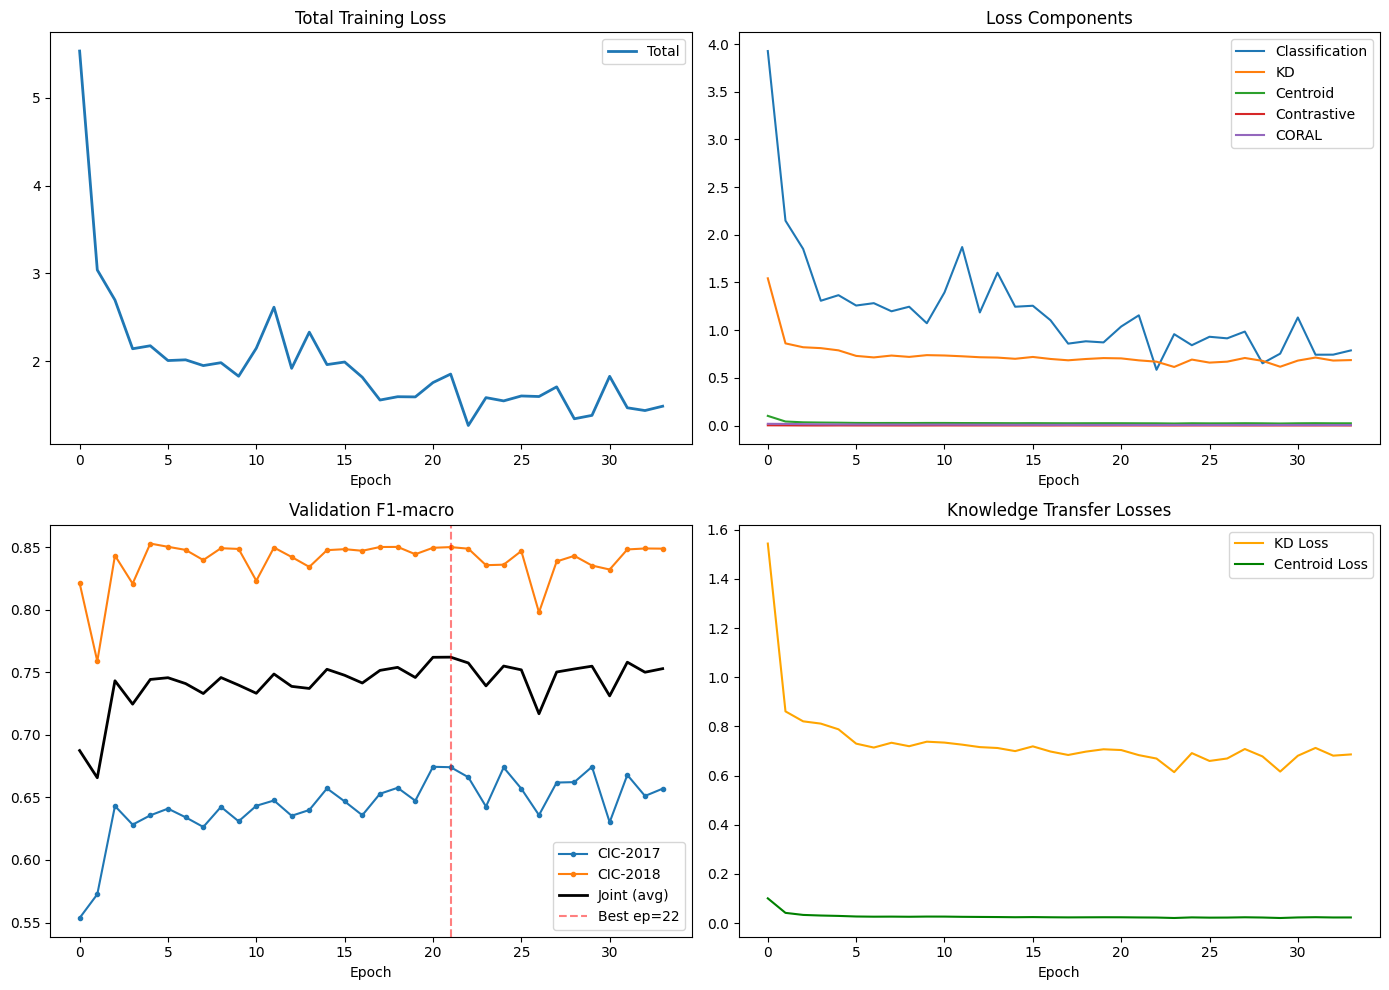

Saved: /home/huyho/earth_predict_env/Project/Model/Domain_Adaption/distillation_training_curves.png


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Total loss
axes[0,0].plot(history['loss'], label='Total', linewidth=2)
axes[0,0].set_title('Total Training Loss'); axes[0,0].set_xlabel('Epoch'); axes[0,0].legend()

# Plot 2: Individual loss components
axes[0,1].plot(history['cls'], label='Classification')
axes[0,1].plot(history['kd'], label='KD')
axes[0,1].plot(history['centroid'], label='Centroid')
axes[0,1].plot(history['contrast'], label='Contrastive')
axes[0,1].plot(history['coral'], label='CORAL')
axes[0,1].set_title('Loss Components'); axes[0,1].set_xlabel('Epoch'); axes[0,1].legend()

# Plot 3: Validation F1-macro
axes[1,0].plot(history['val_f1_17'], label='CIC-2017', marker='.')
axes[1,0].plot(history['val_f1_18'], label='CIC-2018', marker='.')
axes[1,0].plot(history['val_joint'], label='Joint (avg)', linewidth=2, color='black')
axes[1,0].axvline(best_ep-1, color='red', linestyle='--', alpha=0.5, label=f'Best ep={best_ep}')
axes[1,0].set_title('Validation F1-macro'); axes[1,0].set_xlabel('Epoch'); axes[1,0].legend()

# Plot 4: KD + Centroid evolution
axes[1,1].plot(history['kd'], label='KD Loss', color='orange')
axes[1,1].plot(history['centroid'], label='Centroid Loss', color='green')
axes[1,1].set_title('Knowledge Transfer Losses'); axes[1,1].set_xlabel('Epoch'); axes[1,1].legend()

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/distillation_training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {SAVE_DIR}/distillation_training_curves.png")

## 8. Test Set Evaluation
Evaluate the distilled student on held-out test sets for both CIC-2017 and CIC-2018.

CIC-2017 Test — Accuracy: 0.9292, F1-macro: 0.6732
              precision    recall  f1-score   support

      Benign       1.00      0.91      0.95    128128
  BruteForce       0.45      0.99      0.62      1571
        DDoS       0.71      1.00      0.83     14421
         DoS       0.88      0.99      0.93     28431
Infiltration       0.02      1.00      0.04         9

    accuracy                           0.93    172560
   macro avg       0.61      0.98      0.67    172560
weighted avg       0.95      0.93      0.93    172560



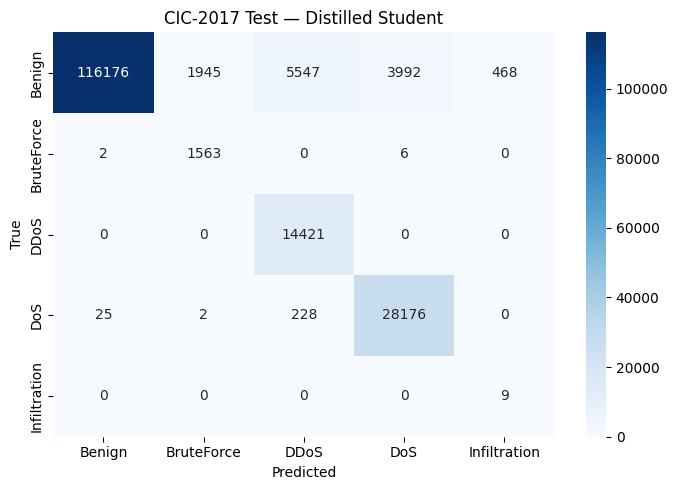

In [14]:
# ═══════════════════════════════════════════════════════════════════
# 8a. CIC-2017 Test Results
# ═══════════════════════════════════════════════════════════════════
p17_te, t17_te, logits17_te = eval_model_logits(student, c17_test_loader, device, dataset_id=0)

acc17 = accuracy_score(t17_te, p17_te)
f1m17 = f1_score(t17_te, p17_te, average='macro', zero_division=0)
print(f"CIC-2017 Test — Accuracy: {acc17:.4f}, F1-macro: {f1m17:.4f}")
print(classification_report(t17_te, p17_te, target_names=UNIFIED_CLASSES, zero_division=0))
plot_confusion(t17_te, p17_te, UNIFIED_CLASSES, "CIC-2017 Test — Distilled Student")

CIC-2018 Test — Accuracy: 0.9092, F1-macro: 0.8509
              precision    recall  f1-score   support

      Benign       0.75      0.80      0.77     10000
  BruteForce       1.00      1.00      1.00     15168
        DDoS       1.00      1.00      1.00     10346
         DoS       1.00      1.00      1.00     12198
Infiltration       0.53      0.45      0.48      5000

    accuracy                           0.91     52712
   macro avg       0.85      0.85      0.85     52712
weighted avg       0.91      0.91      0.91     52712



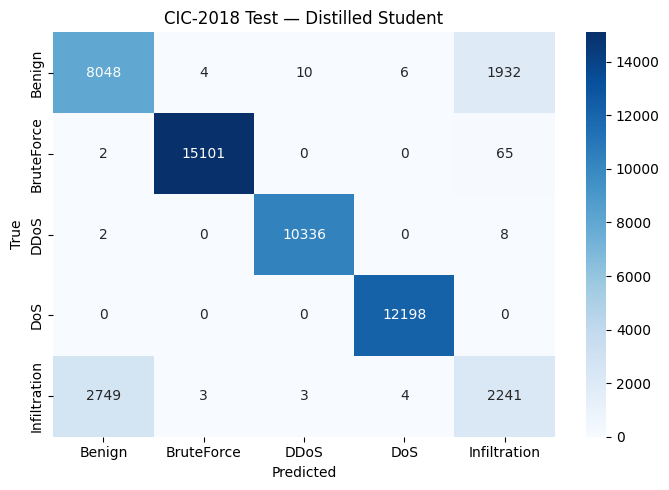

In [15]:
# ═══════════════════════════════════════════════════════════════════
# 8b. CIC-2018 Test Results
# ═══════════════════════════════════════════════════════════════════
p18_te, t18_te, logits18_te = eval_model_logits(student, c18_test_loader, device, dataset_id=1)

acc18 = accuracy_score(t18_te, p18_te)
f1m18 = f1_score(t18_te, p18_te, average='macro', zero_division=0)
print(f"CIC-2018 Test — Accuracy: {acc18:.4f}, F1-macro: {f1m18:.4f}")
print(classification_report(t18_te, p18_te, target_names=UNIFIED_CLASSES, zero_division=0))
plot_confusion(t18_te, p18_te, UNIFIED_CLASSES, "CIC-2018 Test — Distilled Student")

## 9. Embedding Space Visualization
Visualize how the student's projected embeddings align with the teacher's class centroids using t-SNE.

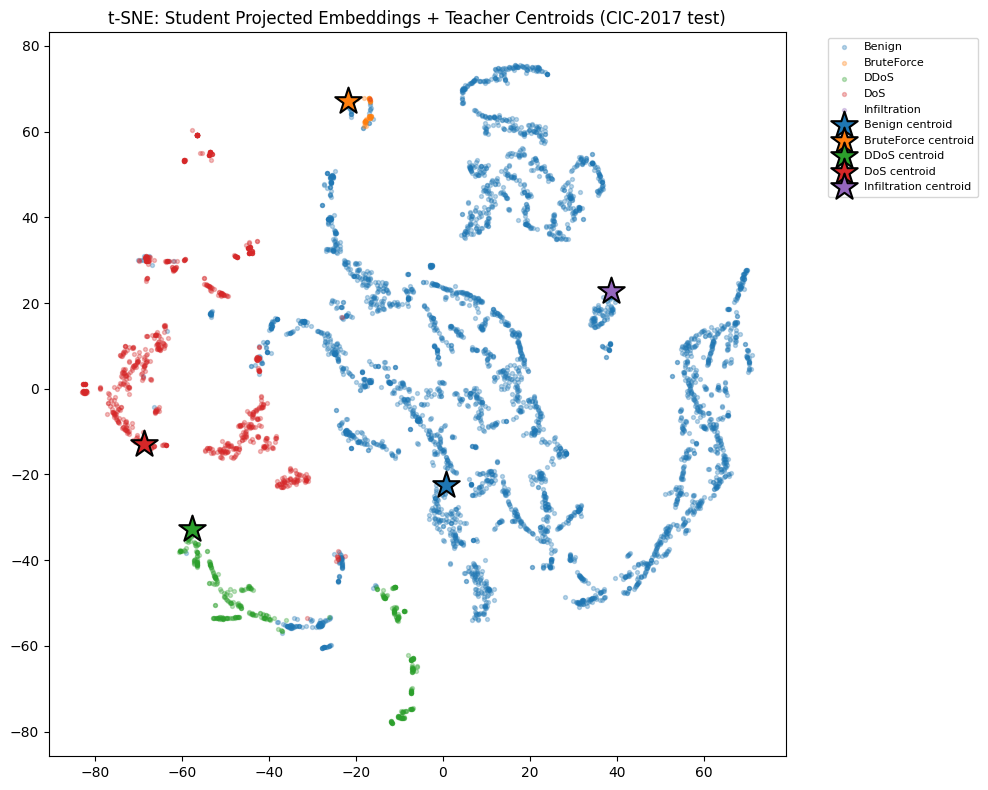

Saved: /home/huyho/earth_predict_env/Project/Model/Domain_Adaption/tsne_distillation_alignment.png


In [16]:
from sklearn.manifold import TSNE

# Collect projected embeddings from CIC-17 test set
student.eval()
proj_all, labels_all = [], []
with torch.no_grad():
    for Xb, yb in c17_test_loader:
        proj = student.get_projection(Xb.to(device)).cpu().numpy()
        proj_all.append(proj)
        labels_all.append(yb.numpy())

proj_all = np.concatenate(proj_all)
labels_all = np.concatenate(labels_all)

# Subsample for t-SNE speed
n_vis = min(5000, len(proj_all))
idx = np.random.RandomState(SEED).choice(len(proj_all), n_vis, replace=False)
proj_sub = proj_all[idx]
labels_sub = labels_all[idx]

# Add teacher centroids
centroids_np = teacher_centroids.cpu().numpy()
combined = np.vstack([proj_sub, centroids_np])

tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
embedded = tsne.fit_transform(combined)

emb_student  = embedded[:n_vis]
emb_centroid = embedded[n_vis:]

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for c in range(NUM_CLASSES):
    mask = labels_sub == c
    ax.scatter(emb_student[mask, 0], emb_student[mask, 1],
               c=colors[c], alpha=0.3, s=8, label=f'{UNIFIED_CLASSES[c]}')

# Plot teacher centroids as large stars
for c in range(NUM_CLASSES):
    ax.scatter(emb_centroid[c, 0], emb_centroid[c, 1],
               c=colors[c], marker='*', s=400, edgecolors='black',
               linewidths=1.5, zorder=10, label=f'{UNIFIED_CLASSES[c]} centroid')

ax.set_title('t-SNE: Student Projected Embeddings + Teacher Centroids (CIC-2017 test)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/tsne_distillation_alignment.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {SAVE_DIR}/tsne_distillation_alignment.png")

## 10. Save Artifacts

In [17]:
# ═══════════════════════════════════════════════════════════════════
# Save teacher, student, scalers, label encoders, and teacher knowledge
# ═══════════════════════════════════════════════════════════════════

# Teacher model
torch.save({
    'model_state_dict': model_nfuq.state_dict(),
    'input_size': len(NFUQ_FEATURES),
    'num_classes': NUM_CLASSES,
    'feature_names': NFUQ_FEATURES,
    'classes': UNIFIED_CLASSES
}, f"{SAVE_DIR}/teacher_nfuq.pth")

# Student model
torch.save({
    'model_state_dict': student.state_dict(),
    'input_size': len(CIC_FEATURES),
    'num_classes_17': NUM_CLASSES,
    'num_classes_18': NUM_CLASSES,
    'teacher_embed_dim': 32,
    'feature_names': CIC_FEATURES,
    'classes': UNIFIED_CLASSES,
    'best_epoch': best_ep,
    'best_joint_f1': best_joint
}, f"{SAVE_DIR}/student_distilled.pth")

# Teacher knowledge (for future use / ablation)
torch.save({
    'centroids': teacher_centroids.cpu(),
    'soft_distributions': teacher_soft_dist.cpu(),
    'temperature': KD_TEMPERATURE,
    'classes': UNIFIED_CLASSES
}, f"{SAVE_DIR}/teacher_knowledge.pth")

# Scalers
with open(f"{SAVE_DIR}/nfuq_scaler.pkl1", 'wb') as f: pickle.dump(nfuq_scaler, f)
with open(f"{SAVE_DIR}/cic17_scaler.pkl1", 'wb') as f: pickle.dump(cic17_scaler, f)
with open(f"{SAVE_DIR}/cic18_scaler.pkl1", 'wb') as f: pickle.dump(cic18_scaler, f)

# Label encoders
with open(f"{SAVE_DIR}/nfuq_label_encoder.pkl1", 'wb') as f: pickle.dump(nfuq_le, f)
with open(f"{SAVE_DIR}/cic17_label_encoder.pkl1", 'wb') as f: pickle.dump(cic17_le, f)
with open(f"{SAVE_DIR}/cic18_label_encoder.pkl1", 'wb') as f: pickle.dump(cic18_le, f)

print("All artifacts saved to:", SAVE_DIR)
for fname in sorted(os.listdir(SAVE_DIR)):
    if not fname.endswith('.ipynb'):
        fpath = os.path.join(SAVE_DIR, fname)
        size_kb = os.path.getsize(fpath) / 1024
        print(f"  {fname:40s} {size_kb:8.1f} KB")

All artifacts saved to: /home/huyho/earth_predict_env/Project/Model/Domain_Adaption
  cic17_label_encoder.pkl1                      0.5 KB
  cic17_scaler.pkl1                             2.3 KB
  cic18_label_encoder.pkl1                      0.5 KB
  cic18_scaler.pkl1                             2.3 KB
  distillation_training_curves.png            221.9 KB
  nfuq_label_encoder.pkl1                       0.5 KB
  nfuq_scaler.pkl1                              1.4 KB
  student_distilled.pth                       949.3 KB
  teacher_knowledge.pth                         2.7 KB
  teacher_nfuq.pth                            250.5 KB
  tsne_distillation_alignment.png             333.5 KB
